In [1]:
print("hello world?")

hello world?


In [2]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI
import os
from dotenv import load_dotenv
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint, HuggingFaceEmbeddings


load_dotenv()

model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.5,
    max_tokens=512,
    google_api_key=os.getenv("GEMINI_API_KEY")
)

llm = HuggingFaceEndpoint(
    repo_id="openai/gpt-oss-20b",
    huggingfacehub_api_token=os.getenv("hf_api_key")
)
chat_model = ChatHuggingFace(llm=llm)

# response = model.invoke("What is the capital of France?")
response_hf = chat_model.invoke("What is the capital of France?")
print(response_hf.content)

d:\anaconda\envs\nlp\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The capital of France is **Paris**.


In [4]:
import os
from dotenv import load_dotenv
from langchain_google_genai import GoogleGenerativeAIEmbeddings

load_dotenv()

def get_llm():
	return ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.5,
    max_tokens=512,
    google_api_key=os.getenv("GEMINI_API_KEY")
)
def get_chat_model_hf():
	llm = HuggingFaceEndpoint(
		repo_id="meta-llama/Llama-3.1-8B-Instruct",
		task="text-generation",
		huggingfacehub_api_token=os.getenv("hf_api_key")
	)
	return ChatHuggingFace(llm=llm)

model = get_chat_model_hf()
print(model.invoke("What is the capital of France?").content)

# def embedding(text: str | list[str]) -> list[float] | list[list[float]]:
#     model = GoogleGenerativeAIEmbeddings(model="gemini-embedding-2")
#     if isinstance(text, str):
#         return model.embed_query(text)
#     elif isinstance(text, list):
#         return model.embed_documents(text)

# print(embedding("What is the capital of France?\n"))
# print(embedding(["What is the capital of France?\n", "What is the capital of Germany?\n"]))

The capital of France is Paris.


In [45]:
len(embedding("What is the capital of France?\n"))

3072

## creating functions for language detection and emotion detection

In [46]:
from transformers import pipeline

# 1. Initialize and download the pipeline from Hugging Face
emotion_classifier = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    return_all_scores=False,
)

# 2. Save the entire pipeline (model, tokenizer, and configs) to your PC
save_path = "./emotion_model"
emotion_classifier.save_pretrained(save_path)

print(f"Model successfully saved to: {save_path}")

Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.13s/it]

Model successfully saved to: ./emotion_model


In [5]:
from transformers import pipeline
from typing import Dict, Any

emotion_classifier = pipeline(
	"text-classification",
	model="../emotion_model",
	return_all_scores=False,
)
def detect_emotion(text: str) -> Dict[str, Any]:
	"""
    Accepts a string and returns the detected emotion and confidence score.
    Useful as a standalone utility or directly inside a LangGraph node.
    """
	if not text or not text.strip():
		return {"emotion": "neutral", "score": 1.0}
	
	result = emotion_classifier(text)[0]
	return {"emotion": result["label"], "score": result["score"]}

print(detect_emotion("I am so happy today!"))
	

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 8749.94it/s]


{'emotion': 'joy', 'score': 0.9615582227706909}


In [18]:
LANG_CLASSIFIER = pipeline(
    "text-classification",
    model="papluca/xlm-roberta-base-language-detection",
    return_all_scores=False,
)

save_path = "../language_classifier"
LANG_CLASSIFIER.save_pretrained(save_path)


Writing model shards: 100%|██████████| 1/1 [00:10<00:00, 10.40s/it]


In [6]:
lang_classifier = pipeline(
	"text-classification",
	model="../language_classifier",
	return_all_scores=False,
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 6931.42it/s]


In [7]:
def detect_language(text: str) -> Dict[str, Any]:
    """
    Accepts a string and returns the detected ISO language code (e.g., 'en', 'fr', 'ar') 
    along with the confidence score.
	
	Args:
		text (str): The input text for which the language needs to be detected.
	Returns:
		Dict[str, Any]: A dictionary containing the detected language and confidence score.
    """
    if not text or not text.strip():
        return {"language": "unknown", "score": 1.0}

    result = lang_classifier(text)[0]

    return {
        "language": result["label"],
        "score": round(result["score"], 4)
    }

print(detect_language("Hello, how are you?"))

{'language': 'en', 'score': 0.8399}


In [8]:
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import PydanticOutputParser

class intent_detection(BaseModel):
    intent: str = Field(..., description="The detected intent of the user query.")
    confidence: float = Field(..., description="The confidence score of the detected intent, between 0 and 1.")

parser = PydanticOutputParser(pydantic_object=intent_detection)

system_prompt = """Classify the user's query into the correct intent and assign a confidence score (0.0 to 1.0).

Intents:
- "greeting": Hellos and introductions.
- "goodbye": Farewells.
- "gratitude": Expressing thanks.
- "asking_mental_health_question": Queries about emotional state, psychology, or mental health support.
- "out_of_scope": Topics completely unrelated to mental health.

Examples:
User: "Hi there"
Intent: greeting
Confidence: 0.95

User: "How do I calm down during a panic attack?"
Intent: asking_mental_health_question
Confidence: 0.98

User: "What is the capital of France?"
Intent: out_of_scope
Confidence: 0.99

User: "Thanks for listening."
Intent: gratitude
Confidence: 0.97

{format_instructions}"""

prompt = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    ("human", "{text}")
])

def intent_user(text: str) -> dict:
    model = get_chat_model_hf()
    chain = prompt | model | parser

    chain_with_retry = chain.with_retry(
        stop_after_attempt=3, 
        wait_exponential_jitter=True
    )
    
    try:
        response = chain_with_retry.invoke({
            "text": text,
            "format_instructions": parser.get_format_instructions()
        })
        return {"intent": response.intent, "confidence": response.confidence}
    except Exception as e:
        print(f"Failed to parse intent after retries. Error: {e}")
        return {"intent": "out_of_scope", "confidence": 0.0}

print(intent_user("Hey, I'm having a really rough day and just needed someone to talk to."))

{'intent': 'asking_mental_health_question', 'confidence': 0.95}


In [57]:
print(intent_user("Hey, I'm having a really rough day and just needed someone to talk to."))
print(intent_user("I want to start a new workout routine to help with my low energy. Any tips?"))
print(intent_user("That makes sense, thanks! By the way, how do I deal with burnout?"))
print(intent_user("Can you recommend a good book on the biology of the brain?"))

{'intent': 'asking_mental_health_question', 'confidence': 0.92}
{'intent': 'asking_mental_health_question', 'confidence': 0.58}
{'intent': 'asking_mental_health_question', 'confidence': 0.85}
{'intent': 'asking_mental_health_question', 'confidence': 0.8}


## translation model

In [9]:
from transformers import MarianTokenizer, MarianMTModel

In [10]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
model_name = "Helsinki-NLP/opus-mt-mul-en"
save_directory = "../many_to_one_translator"

print(f"Downloading '{model_name}' explicitly using Marian classes...")
tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name)

print("Saving to local drive...")
tokenizer.save_pretrained(save_directory)
model.save_pretrained(save_directory)

print("Download complete!")

d:\anaconda\envs\nlp\lib\site-packages\transformers\models\marian\tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")
d:\anaconda\envs\nlp\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\basil\.cache\huggingface\hub\models--Helsinki-NLP--opus-mt-mul-en. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windo

Saving to local drive...


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.16s/it]

Download complete!


In [13]:
from transformers import MarianTokenizer, MarianMTModel

# Point this to your local folder
local_model_path = "../many_to_one_translator"

print("Loading local translator directly (No Pipeline)...")

# 1. Load the objects
tokenizer = MarianTokenizer.from_pretrained(local_model_path)
model = MarianMTModel.from_pretrained(local_model_path)

test_sentences = [
    "Hola, estoy aprendiendo a programar.",   # Spanish
    "Bonjour, comment allez-vous ?",          # French
    "Guten Tag, das ist ein Test.",           # German
    "Ciao, il codice funziona perfettamente." # Italian
]

print("\n--- Translation Results ---")
for text in test_sentences:
    # 2. Tokenize the input directly
    # return_tensors="pt" ensures it is formatted for PyTorch
    inputs = tokenizer(text, return_tensors="pt", padding=True)
    
    # 3. Generate the translated tokens
    translated_tokens = model.generate(**inputs)
    
    # 4. Decode the tokens back into a readable string
    english_translation = tokenizer.decode(translated_tokens[0], skip_special_tokens=True)
    
    print(f"Original: {text}")
    print(f"English:  {english_translation}\n")

d:\anaconda\envs\nlp\lib\site-packages\transformers\models\marian\tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Loading local translator directly (No Pipeline)...


Loading weights: 100%|██████████| 254/254 [00:00<00:00, 7257.42it/s]



--- Translation Results ---
Original: Hola, estoy aprendiendo a programar.
English:  Hey, I'm learning how to program.

Original: Bonjour, comment allez-vous ?
English:  Hello, how are you?

Original: Guten Tag, das ist ein Test.
English:  Good day, that's a test.

Original: Ciao, il codice funziona perfettamente.
English:  Hi, the code works perfectly.



In [20]:
def translate_to_english(text: str) -> str:
	"""
	takes non-english text and translate it to english.
	
	Args:
		text (str): The input text in any language that needs to be translated to English
	Returns:
		str: The translated text in English.
	"""
	inputs = tokenizer(text, return_tensors="pt", padding=True)
	inputs.to(device)
	model.to(device)
	translated_tokens = model.generate(**inputs)
	english_translation = tokenizer.decode(translated_tokens[0], skip_special_tokens=True)
	return english_translation

test = translate_to_english("Hola, estoy aprendiendo a programar.")
print(test)

Hey, I'm learning how to program.


## creating nodes for self reflective rag at first

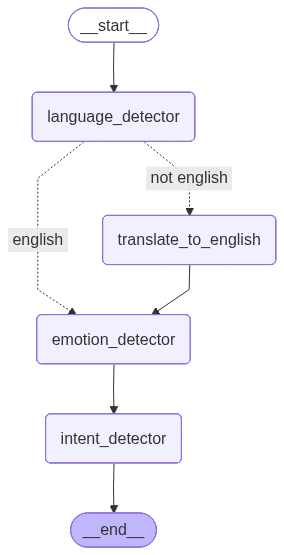

In [ ]:
from typing import TypedDict, Optional
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END

class ChatbotState(TypedDict):
	# default states
	user_input: str
	detect_language: str
	detected_emotion: str
	intent: str
	translated_query: str
	
	# states for reflective rag
	search_query: str  #default: user_input changed if query rewrite
	retrieved_docs: list[str]
	is_context_relevant: str
	checking_attempts: int
	final_response: str

def language_detection_node(ChatbotState) -> dict:
	"""
	Takes user input from the chatbot state and detects the language using the detect_language function.
	Updates the chatbot state with the detected language and confidence score.

	Args:
		ChatbotState (TypedDict): The current state of the chatbot containing user input and other relevant information.

	Returns:
		dict: A dictionary containing the updated chatbot state with detected language and confidence score.
	"""
	user_input = ChatbotState["user_input"]
	language_info = detect_language(user_input)
	print(f"\nDetected Language: {language_info['language']}, Confidence Score: {language_info['score']}\n")
	return {
		"detect_language": language_info["language"]
	}

def is_language_english(state: ChatbotState) -> str:
    if state.get("detect_language") == "en":
        return "english"
    return "not english"

def translate_to_english_node(state: ChatbotState) -> dict:
    if state.get("detect_language") != "en":
        translated = translate_to_english(state["user_input"])
        return {"translated_query": translated}
    
    return {"translated_query": state["user_input"]}

def emotion_detection_node(ChatbotState) -> dict:
	"""
	Takes user input from the chatbot state and detects the emotion using the detect_emotion function.
	Updates the chatbot state with the detected emotion.

	Args:
		ChatbotState (TypedDict): The current state of the chatbot containing user input and other relevant information.

	Returns:
		dict: A dictionary containing the updated chatbot state with detected emotion.
	"""
	user_input = ChatbotState["user_input"]
	emotion_info = detect_emotion(user_input)
	print(f"\nDetected Emotion: {emotion_info['emotion']}\n")
	return {"detected_emotion": emotion_info["emotion"]}

def intent_detection_node(ChatbotState) -> dict:
	"""
	Takes user input from the chatbot state and detects the intent using the intent_user function.
	Updates the chatbot state with the detected intent and confidence score.

	Args:
		ChatbotState (TypedDict): The current state of the chatbot containing user input and other relevant information.

	Returns:
		dict: A dictionary containing the updated chatbot state with detected intent and confidence score.
	"""
	user_input = ChatbotState["user_input"]
	intent_info = intent_user(user_input)
	print(f"\nDetected Intent: {intent_info['intent']}, Confidence Score: {intent_info['confidence']}\n")
	return {
		"intent": intent_info["intent"]
	}

graph = StateGraph(ChatbotState)
graph.add_node(
	"language_detector",
	language_detection_node,
)
graph.add_node(
	"emotion_detector",
	emotion_detection_node,
)
graph.add_node(
	"intent_detector",
	intent_detection_node,
)
graph.add_node(
	"translate_to_english",
	translate_to_english_node,
)
graph.add_edge(START, "language_detector")
graph.add_conditional_edges(
	"language_detector",
	is_language_english,
	{
		"english": "emotion_detector",
		"not english": "translate_to_english"
	}
)
graph.add_edge("translate_to_english", "emotion_detector")
graph.add_edge("emotion_detector", "intent_detector")
graph.add_edge("intent_detector", END)

app = graph.compile()
app


In [30]:
result = app.invoke(
	{
	"user_input": "اهلا انا متعب للغاية"
	}
)
print(result)


Detected Language: ar, Confidence Score: 0.994


Detected Emotion: neutral



InvalidUpdateError: Expected dict, got Oh, I'm so tired.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_GRAPH_NODE_RETURN_VALUE